# 🏏 IPL Cricket Match Analysis Project

## 🎯 Problem Statement
The Indian Premier League (IPL) is a professional Twenty20 cricket league in India. The league generates massive amounts of data every season. This project aims to perform **Exploratory Data Analysis (EDA)** on historical IPL data to extract meaningful insights.

We will analyze:
1. Team performances and win percentages.
2. The impact of the toss on the match outcome.
3. Venue-wise scoring trends.
4. Top-performing players (Run Scorers and Wicket Takers).
5. Season-wise match trends.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 📂 1. Dataset Overview
We will load the `matches.csv` and `deliveries.csv` datasets directly from public GitHub repositories.
- `matches.csv`: Contains match-level details (Teams, Venue, Toss, Winner, etc.)
- `deliveries.csv`: Contains ball-by-ball details (Batsman, Bowler, Runs, Wickets, etc.)

In [30]:
# URLs for the datasets
matches_url = 'matches.csv'
deliveries_url = 'deliveries.csv'
# Load the datasets
print("Loading datasets...")
try:
    df_matches = pd.read_csv(matches_url)
    df_deliveries = pd.read_csv(deliveries_url)
    print("Datasets loaded successfully!")
except Exception as e:
    print(f"Error loading datasets: {e}")

Loading datasets...
Datasets loaded successfully!


In [31]:
# Quick look at the matches data
df_matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


In [32]:
# Quick look at the deliveries data
df_deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


## 🧹 2. Data Preprocessing
Before analyzing the data, we must clean it. This involves:
- Checking for missing values.
- Handling duplicates.
- Formatting data appropriately.

In [33]:
# Check for missing values in matches dataset
df_matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              0
umpire2              0
umpire3            577
dtype: int64

In [34]:
# Fill missing 'city' values with 'Unknown'
df_matches['city'] = df_matches['city'].fillna('Unknown')

# Drop umpire3 as it has mostly missing values
if 'umpire3' in df_matches.columns:
    df_matches = df_matches.drop('umpire3', axis=1)

# Fill other umpire missing values
df_matches['umpire1'] = df_matches['umpire1'].fillna('Unknown')
df_matches['umpire2'] = df_matches['umpire2'].fillna('Unknown')

# Fill missing player_of_match and winner (happens in no-result matches)
df_matches['player_of_match'] = df_matches['player_of_match'].fillna('No Result')
df_matches['winner'] = df_matches['winner'].fillna('No Result')

In [35]:
# Remove duplicate matches if any
print(f"Shape before dropping duplicates: {df_matches.shape}")
df_matches = df_matches.drop_duplicates()
print(f"Shape after dropping duplicates: {df_matches.shape}")

Shape before dropping duplicates: (577, 17)
Shape after dropping duplicates: (577, 17)


In [36]:
# Replace some old team names with new ones for consistency
team_replacements = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Pune Warriors': 'Pune Warriors India',
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad'
}
df_matches.replace(team_replacements, inplace=True)
df_deliveries.replace(team_replacements, inplace=True)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN


## 📊 3. Exploratory Data Analysis (EDA) & Visualizations

### 🏆 3.1 Most Successful Teams
Let's see which team has won the most matches across all seasons.

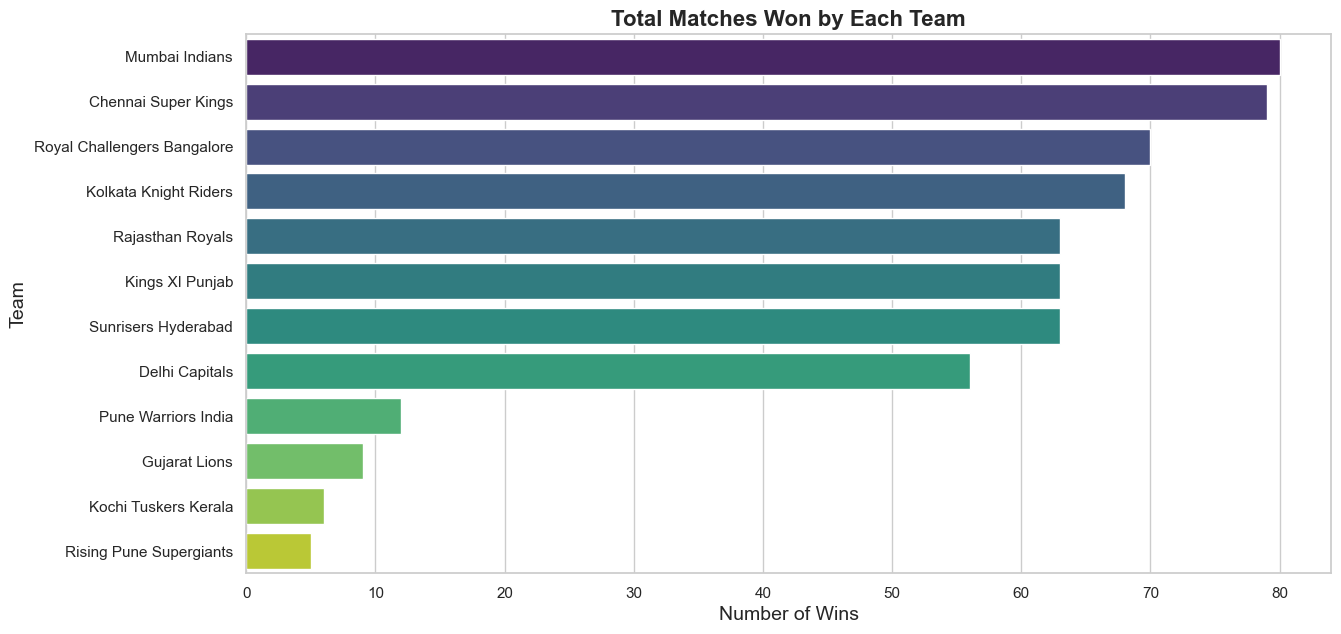

In [37]:
# Filter out 'No Result' matches
valid_matches = df_matches[df_matches['winner'] != 'No Result']
team_wins = valid_matches['winner'].value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(x=team_wins.values, y=team_wins.index, hue=team_wins.index, palette='viridis', legend=False)
plt.title('Total Matches Won by Each Team', fontsize=16, weight='bold')
plt.xlabel('Number of Wins', fontsize=14)
plt.ylabel('Team', fontsize=14)
plt.show()

### 🪙 3.2 Toss Impact on Match Results
Does winning the toss mean you have a higher chance of winning the match?

Percentage of matches won by the team that won the toss: 50.70%


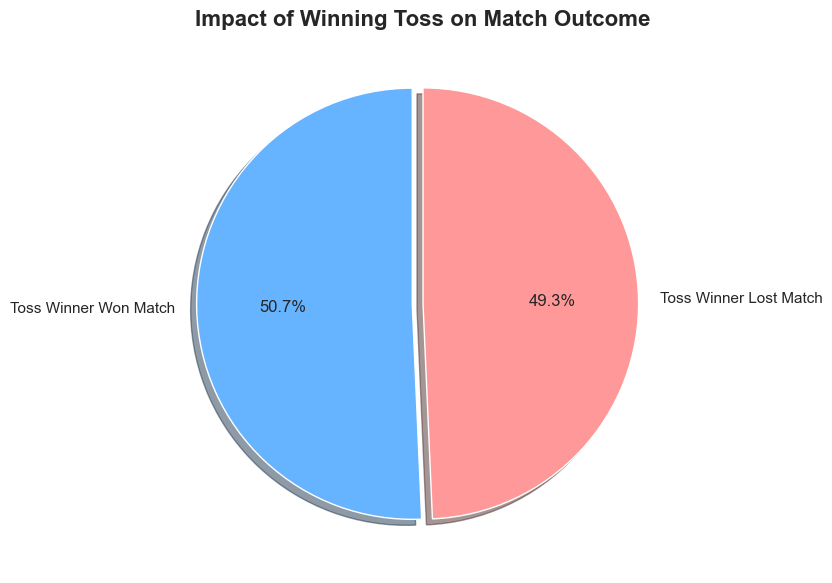

In [21]:
# Check if toss winner is the match winner
toss_match_winner = df_matches[df_matches['toss_winner'] == df_matches['winner']]
win_percentage = (len(toss_match_winner) / len(valid_matches)) * 100

print(f"Percentage of matches won by the team that won the toss: {win_percentage:.2f}%")

# Pie Chart
labels = ['Toss Winner Won Match', 'Toss Winner Lost Match']
sizes = [len(toss_match_winner), len(valid_matches) - len(toss_match_winner)]
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0), shadow=True)
plt.title('Impact of Winning Toss on Match Outcome', fontsize=16, weight='bold')
plt.show()

### 📈 3.3 Win Percentage by Team

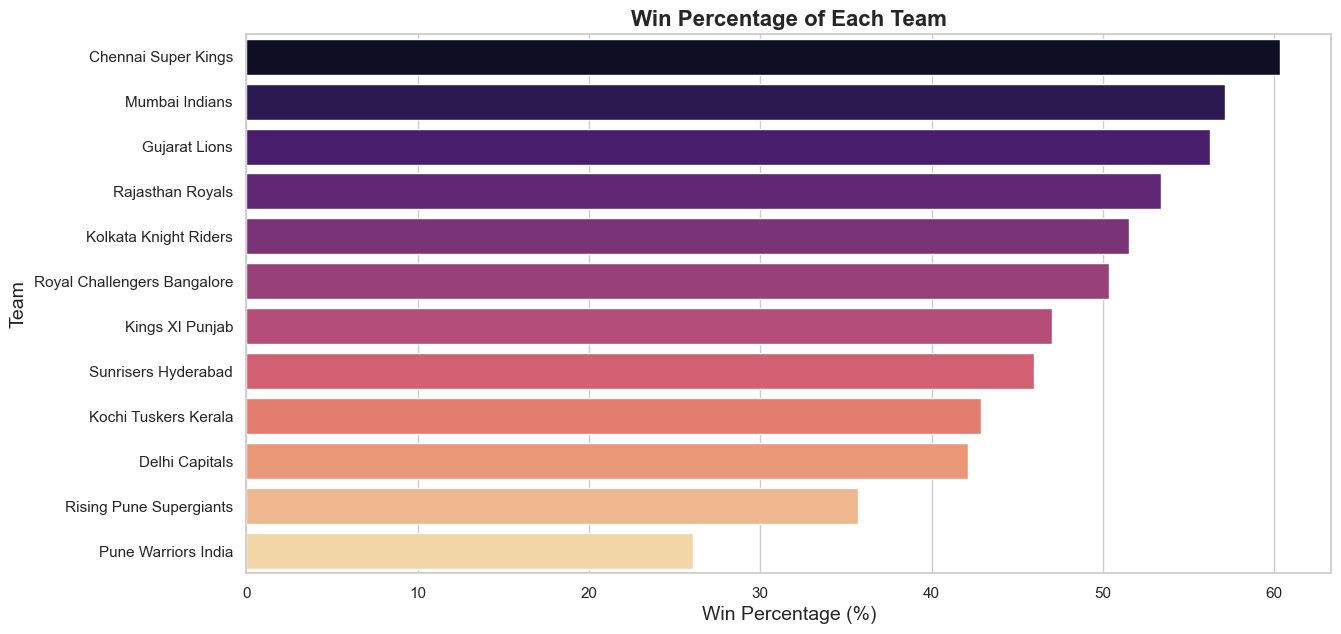

In [22]:
total_matches_played = df_matches['team1'].value_counts() + df_matches['team2'].value_counts()
win_percentage_df = pd.DataFrame({'Total Matches': total_matches_played, 'Wins': team_wins})
win_percentage_df['Win Percentage'] = (win_percentage_df['Wins'] / win_percentage_df['Total Matches']) * 100
win_percentage_df = win_percentage_df.sort_values(by='Win Percentage', ascending=False).dropna()

plt.figure(figsize=(14, 7))
sns.barplot(x=win_percentage_df['Win Percentage'], y=win_percentage_df.index, hue=win_percentage_df.index, palette='magma', legend=False)
plt.title('Win Percentage of Each Team', fontsize=16, weight='bold')
plt.xlabel('Win Percentage (%)', fontsize=14)
plt.ylabel('Team', fontsize=14)
plt.show()

### 🏟️ 3.4 Top Venues for IPL Matches

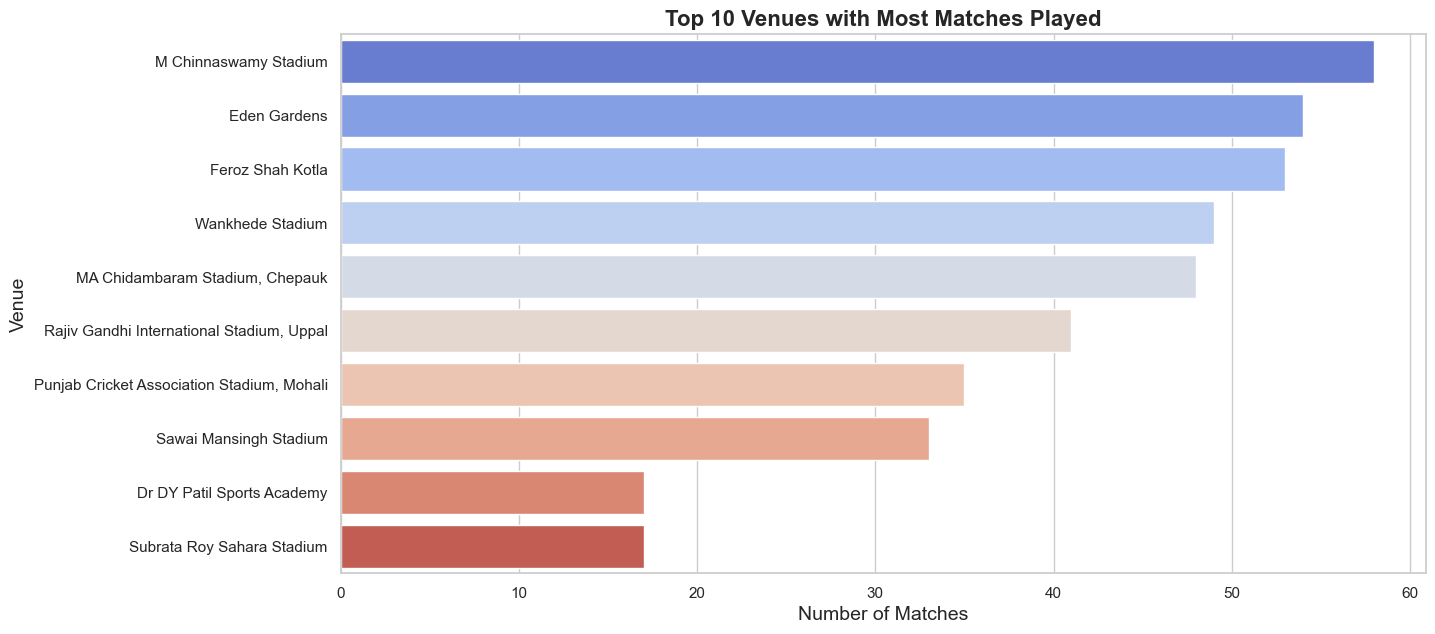

In [23]:
venue_counts = df_matches['venue'].value_counts().head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x=venue_counts.values, y=venue_counts.index, hue=venue_counts.index, palette='coolwarm', legend=False)
plt.title('Top 10 Venues with Most Matches Played', fontsize=16, weight='bold')
plt.xlabel('Number of Matches', fontsize=14)
plt.ylabel('Venue', fontsize=14)
plt.show()

### 🗓️ 3.5 Season-wise Trends (Matches Played per Season)

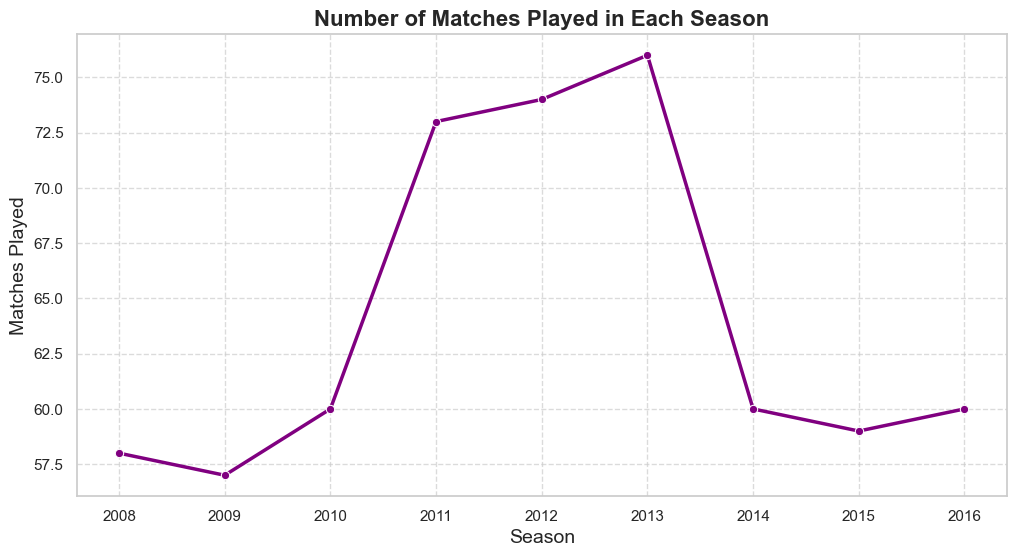

In [24]:
matches_per_season = df_matches['season'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=matches_per_season.index, y=matches_per_season.values, marker='o', color='purple', linewidth=2.5)
plt.title('Number of Matches Played in Each Season', fontsize=16, weight='bold')
plt.xlabel('Season', fontsize=14)
plt.ylabel('Matches Played', fontsize=14)
plt.xticks(matches_per_season.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 🏏 3.6 Top Run Scorers (Batsmen)

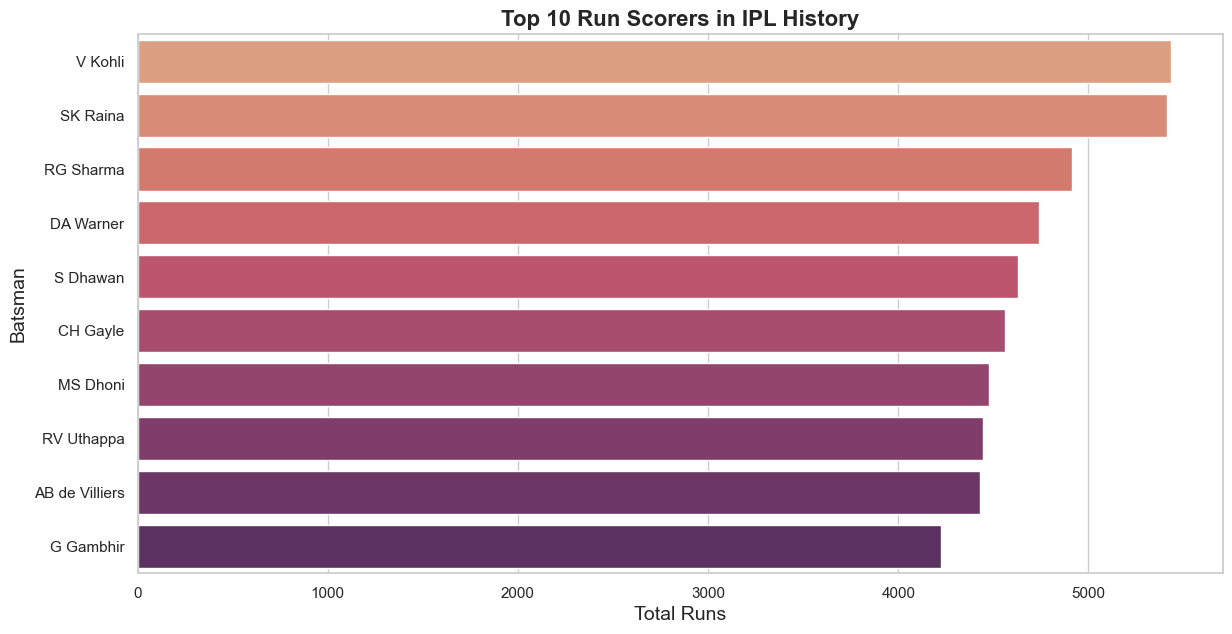

In [25]:
top_batsmen = df_deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, hue=top_batsmen.index, palette='flare', legend=False)
plt.title('Top 10 Run Scorers in IPL History', fontsize=16, weight='bold')
plt.xlabel('Total Runs', fontsize=14)
plt.ylabel('Batsman', fontsize=14)
plt.show()

### 🎯 3.7 Top Wicket Takers (Bowlers)

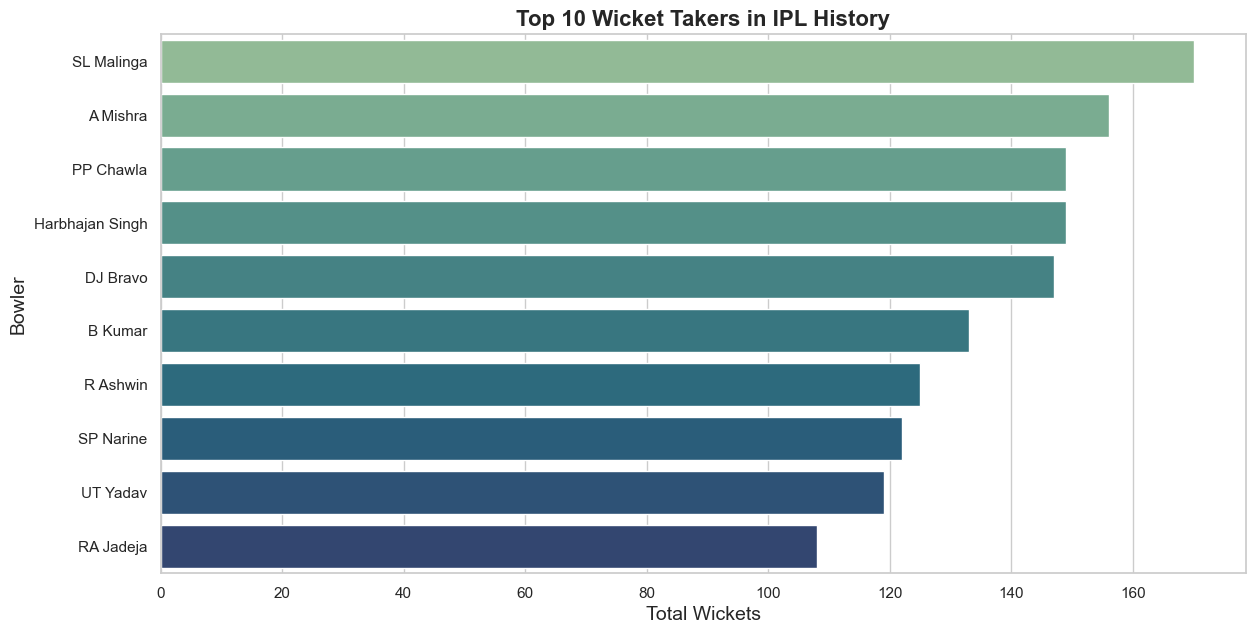

In [26]:
# Filter out run outs, retired hurts, etc., to only count bowler wickets
bowler_wickets = df_deliveries[df_deliveries['dismissal_kind'].isin(['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled'])]
top_bowlers = bowler_wickets.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, hue=top_bowlers.index, palette='crest', legend=False)
plt.title('Top 10 Wicket Takers in IPL History', fontsize=16, weight='bold')
plt.xlabel('Total Wickets', fontsize=14)
plt.ylabel('Bowler', fontsize=14)
plt.show()

### 🔥 3.8 Run Distribution (Histogram)
Let's see the distribution of runs scored by teams per match.

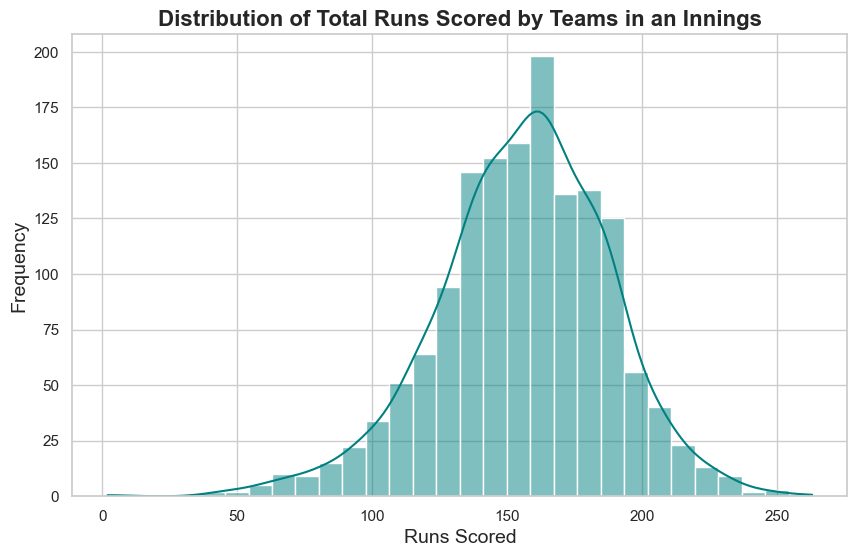

In [27]:
team_match_runs = df_deliveries.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.histplot(team_match_runs['total_runs'], bins=30, kde=True, color='teal')
plt.title('Distribution of Total Runs Scored by Teams in an Innings', fontsize=16, weight='bold')
plt.xlabel('Runs Scored', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

## 💡 4. Conclusion
Based on our exploratory data analysis, we can draw the following insights:
1. **Mumbai Indians (MI) and Chennai Super Kings (CSK)** consistently top the charts in terms of absolute wins and win percentages.
2. **Winning the toss** provides only a marginal advantage (~51% win rate), suggesting that match performance holds more weight than just the toss outcome.
3. Iconic venues like **Eden Gardens and M. Chinnaswamy Stadium** have hosted the most matches.
4. **Virat Kohli, Suresh Raina, and Rohit Sharma** dominate the historical run-scoring charts.
5. **Lasith Malinga and Amit Mishra** have historically been incredibly effective at taking wickets.
6. A typical IPL innings score generally falls between **140 and 180 runs**, with a few extreme high-scoring outliers.

---
*Analysis completed using Pandas, NumPy, Matplotlib, and Seaborn.*